# Noteboooks

## 1. Thiết lập và chuẩn bị dữ liệu 

In [55]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))
from src.get_data import get_data_processed
from src.models import run_all_models, run_single_model
import plotly.express as px
import plotly.graph_objects as go

from src.get_data import get_data_processed
from src.models import run_all_models, run_single_model
from src.visualization import plot_prediction_vs_actual

In [37]:
df = get_data_processed("final_m1.csv")
# df.drop(['is_pre_tet_rush', 'is_tet_holiday', 'is_double_day'], axis=1, inplace=True)
df_aov = df[['date', 'average_order_value']]
df_aov['date'] = pd.to_datetime(df_aov['date'])

Đã đọc thành công dữ liệu từ: D:\datathon\vimchanhxa-datathon\data\processed\final_m1.csv


## 2. Dự đoán AOV

Vì AOV được tính toán dựa trên `Revenue` là thành phần chúng ta chưa biết và đang cần dự đoán, nên ở đây ta sẽ dự đoán AOV dựa trên các dữ liệu thời gian.

### 2.1 Phân tích và trực quan hóa

In [38]:
# Tính trung bình động 7 ngày
df_aov['aov_ma7'] = df_aov['average_order_value'].rolling(window=7).mean()

# Plotly tương tác
fig = go.Figure()

# AOV gốc
fig.add_trace(go.Scatter(
    x=df_aov['date'], 
    y=df_aov['average_order_value'],
    mode='lines',
    name='AOV gốc',
    line=dict(color='steelblue', width=1),
    opacity=0.5
))

# MA 7 ngày
fig.add_trace(go.Scatter(
    x=df_aov['date'], 
    y=df_aov['aov_ma7'],
    mode='lines',
    name='MA 7 ngày',
    line=dict(color='red', width=2)
))

fig.update_layout(
    title='Average Order Value theo thời gian',
    xaxis_title='Ngày',
    yaxis_title='AOV',
    hovermode='x unified'
)

fig.show()

# Thống kê cơ bản
print("Thống kê AOV:")
print(df_aov['average_order_value'].describe())

Thống kê AOV:
count     3833.000000
mean     26754.073894
std       5765.813056
min      10983.747640
25%      23398.562532
50%      26714.650066
75%      30420.691717
max      55063.135000
Name: average_order_value, dtype: float64


Thông qua quan sát và tương tác với biểu đồ:
- Dữ liệu có dấu hiệu tăng nhẹ
- Mô hình có chu kỳ theo năm: Luôn giảm mạnh từ bắt đầu từ giữa tháng 11 và dạt thấp nhất tại tháng 12
- Thường xuyên giảm mạnh vào tháng 8 - tháng 9 các năm lẻ
- Không có chu kỳ theo tháng, ngày

### 2.2 Trích xuất feature:

In [39]:
df_aov['year'] = df_aov['date'].dt.year
df_aov['month_sin'] = np.sin(2 * np.pi * df_aov['date'].dt.month / 12)
df_aov['month_cos'] = np.cos(2 * np.pi * df_aov['date'].dt.month / 12)

df_aov['is_year_end'] = ((df_aov['date'].dt.month == 11) & (df_aov['date'].dt.day >= 15) | (df_aov['date'].dt.month == 12))
df_aov['is_August_odd_year'] = (df_aov['year'] % 2 == 1) & (df_aov['date'].dt.month == 8)

df_aov['rolling_mean_30'] = df_aov['average_order_value'].rolling(window=182).mean()

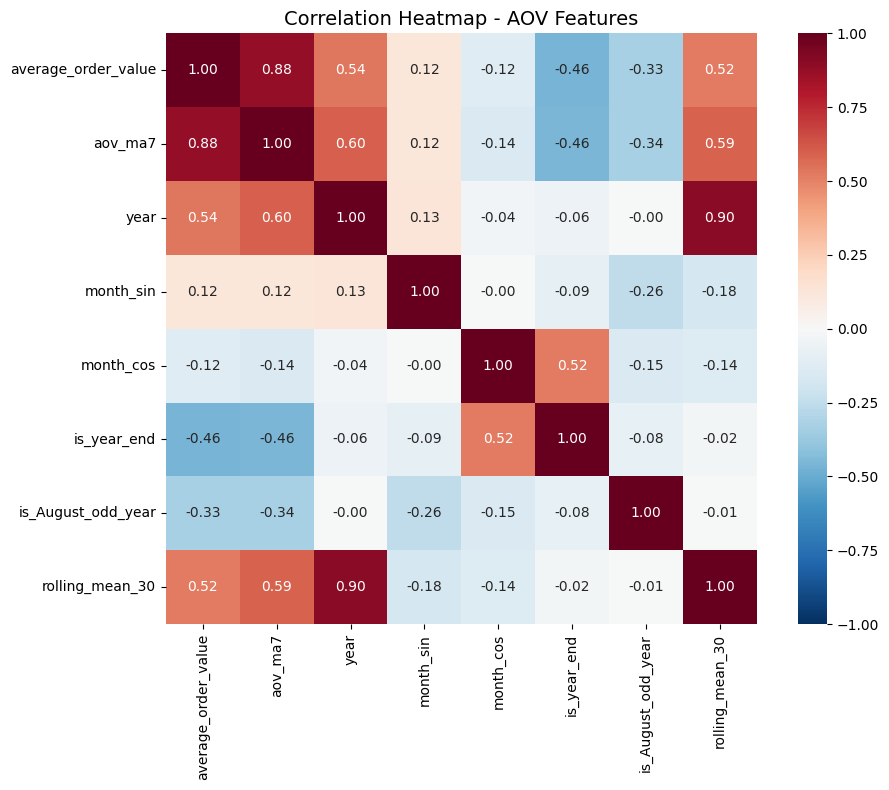


Ma trận Correlation:
                     average_order_value  aov_ma7  year  month_sin  month_cos  \
average_order_value                 1.00     0.88  0.54       0.12      -0.12   
aov_ma7                             0.88     1.00  0.60       0.12      -0.14   
year                                0.54     0.60  1.00       0.13      -0.04   
month_sin                           0.12     0.12  0.13       1.00      -0.00   
month_cos                          -0.12    -0.14 -0.04      -0.00       1.00   
is_year_end                        -0.46    -0.46 -0.06      -0.09       0.52   
is_August_odd_year                 -0.33    -0.34 -0.00      -0.26      -0.15   
rolling_mean_30                     0.52     0.59  0.90      -0.18      -0.14   

                     is_year_end  is_August_odd_year  rolling_mean_30  
average_order_value        -0.46               -0.33             0.52  
aov_ma7                    -0.46               -0.34             0.59  
year                       -0.06

In [40]:
import seaborn as sns

# Chọn các cột numeric để tính correlation
numeric_cols = ['average_order_value', 'aov_ma7', 'year', 'month_sin', 'month_cos', 
                'is_year_end', 'is_August_odd_year', 'rolling_mean_30']
df_corr = df_aov[numeric_cols].copy()

# Tính ma trận tương quan
corr_matrix = df_corr.corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap - AOV Features', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMa trận Correlation:")
print(corr_matrix.round(2))

## 3. Huấn luyện và đánh giá các mô hình
Để tìm ra mô hình tốt nhất cho bài toán cũng như bộ dữ liệu features của chúng tôi, chúng tôi đã tổng hợp lại một vài mô hình phổ biến nhất với `random_seed = 42` và những thông số cơ bản cho các mô hình. Điều này giúp tôi đánh giá công bằng được mô hình nào tốt nhất hiện tại và sẽ được sử dụng để tối ưu. Dưới đây là danh sách các models của chúng tôi
- Linear (Baseline):
    - LinearRegression
- Tree:
    - DecisionTree
    - RandomForest
    - ExtraTrees
- Boosting (sklearn):
    - HistGradientBoosting
    - AdaBoost
- External Boosting
    - XGBoost
    - CatBoost
    - LightGBM

Tất cả models sẽ được đánh giá dựa trên 4 tiêu chí sau: `MAE`, `RMSE`, `MAPE` và `R-squared` 

In [48]:
target = 'average_order_value'
# Loại bỏ cột date và target khỏi features
features = [col for col in df_aov.columns if col not in [target, 'date']]
print("Features:", features)

Features: ['aov_ma7', 'year', 'month_sin', 'month_cos', 'is_year_end', 'is_August_odd_year', 'rolling_mean_30']


In [49]:
evaluate_models = run_all_models(df_aov, target_col=target, feature_cols=features)
evaluate_models

Done: LinearRegression
Done: DecisionTree
Done: RandomForest
Done: ExtraTrees
Done: HistGradientBoosting
Done: AdaBoost
Done: LightGBM
Done: XGBoost
Done: CatBoost


,Model,MAE,RMSE,MAPE,R-squared
0,LinearRegression,2596.771666,3351.724500,7.996533,0.603138
1,LightGBM,2760.306097,3538.357039,8.341398,0.557711
2,CatBoost,2748.325693,3548.789645,8.378696,0.555099
3,HistGradientBoosting,2801.009720,3563.478693,8.508239,0.551408
4,RandomForest,2786.018018,3564.407369,8.507496,0.551174
5,ExtraTrees,2778.973538,3601.819298,8.533126,0.541703
6,AdaBoost,2801.994151,3610.025218,8.602584,0.539613
7,XGBoost,3233.296172,4120.348141,9.815148,0.400249
8,DecisionTree,4155.300716,5203.487995,12.589426,0.043484


In [50]:
best_model = evaluate_models['Model'].iloc[0]
print("Model tốt nhất là:", best_model)

Model tốt nhất là: LinearRegression


In [52]:
val_result, model, metrics = run_single_model(model_name=best_model, df=df_aov, target_col=target, feature_cols=features)

print("Metrics:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value}")

Metrics:
MAE: 2596.771666182451
RMSE: 3351.724499830522
MAPE: 7.996533082599526
R-squared: 0.6031379276557071


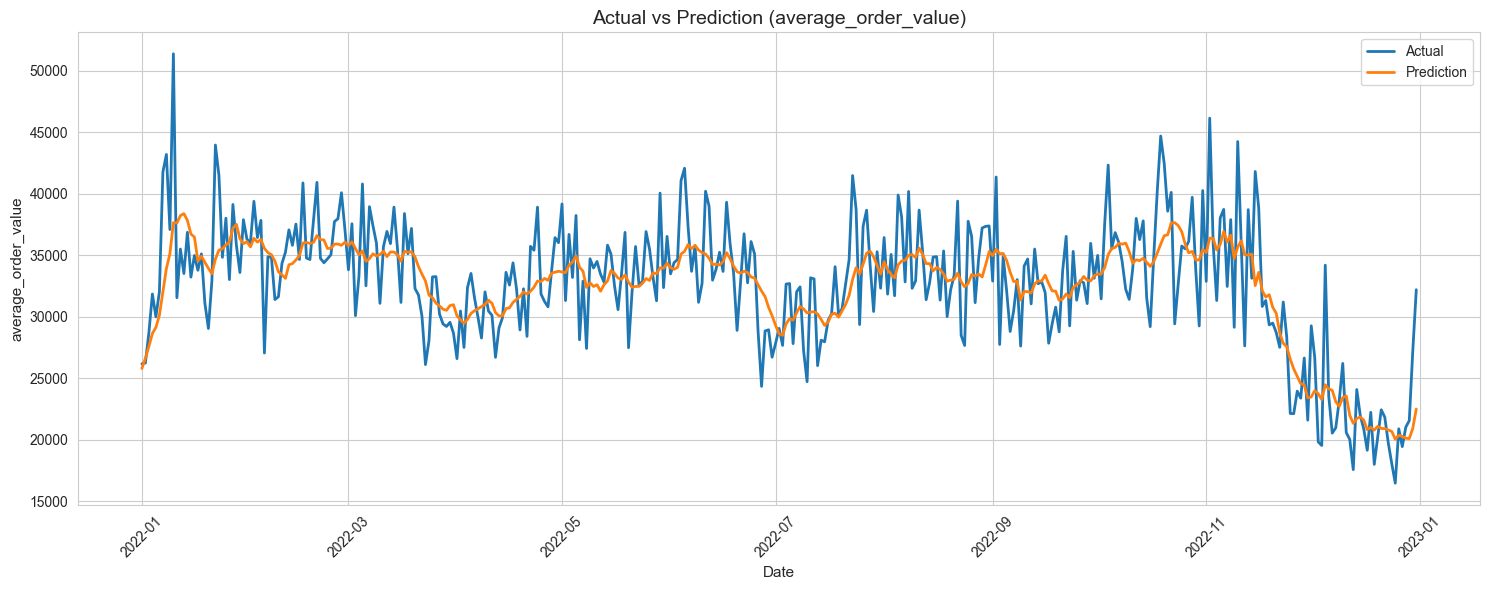

In [56]:
plot_prediction_vs_actual(val_result, target = target)